In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time
import os

os.makedirs('data', exist_ok=True)

In [2]:
FEE_RATE = 0.001
CAPITAL = 1_000 # $1000 per side, $2000 per trade
FIXED_END = int(pd.Timestamp('2026-07-05').timestamp() * 1000)
NUM_CANDLES = 20_000
TRAIN_END = NUM_CANDLES // 2

In [3]:
def get_historical_data(symbol, interval='60', num_candles=NUM_CANDLES, end=FIXED_END):
    
    # for live data, pass end=int(time.time() * 1000) as an argument

    cache = f'data/{symbol}.csv'
    if os.path.exists(cache):
        df = pd.read_csv(cache)
        if len(df) >= num_candles:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            return df.iloc[:num_candles]
    
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    df = df.iloc[:num_candles]
    df.to_csv(f'data/{symbol}.csv', index=False)
    return df

def get_turnover_24h(symbol, end=FIXED_END):
    url = 'https://api.bybit.com/v5/market/kline'
    params = {
        'category': 'spot',
        'symbol': symbol,
        'interval': '60',
        'limit': 24,
        'end': end
    }
    r = requests.get(url, params=params)
    data = r.json()['result']['list']
    time.sleep(0.01)
    return sum(float(c[6]) for c in data)

def backtest(price_a, price_b, zscore, beta, capital=CAPITAL, fee_rate=FEE_RATE):
    position = 0
    pnl = 0
    units_a = 0
    units_b = 0
    pnl_history = []
    deployed = 0

    for i in range(1, len(zscore)):
        if position == 0 and abs(zscore[i]) > 2:
            position = -1 if zscore[i] > 2 else 1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
            units_a = capital / entry_price_a
            units_b = beta * units_a
            deployed = max(deployed, units_a * entry_price_a + units_b * entry_price_b)
            pnl -= fee_rate * (units_a * entry_price_a + units_b * entry_price_b)
        elif position != 0 and abs(zscore[i]) < 0.5:
            pnl += position * units_a * (price_a[i] - entry_price_a)
            pnl += position * units_b * (entry_price_b - price_b[i])
            pnl -= fee_rate * (units_a * price_a[i] + units_b * price_b[i])
            position = 0

        if position != 0:
            unrealised = position * units_a * (price_a[i] - entry_price_a)
            unrealised += position * units_b * (entry_price_b - price_b[i])
            pnl_history.append(pnl + unrealised)
        else:
            pnl_history.append(pnl)

    if position != 0:
        pnl_history[-1] -= fee_rate * (units_a * price_a[-1] + units_b * price_b[-1])

    initial_equity = deployed if deployed > 0 else capital * 2
    equity_history = [initial_equity + p for p in pnl_history]
    return equity_history

def analyse_pair(symbol_a, symbol_b, data):
    df_a = data[symbol_a]
    df_b = data[symbol_b]
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    n = min(len(price_a), len(price_b))

    if n < NUM_CANDLES:
        print(f"insufficient data for {symbol_a}|{symbol_b}")
        return 
        
    price_a = price_a[:n]
    price_b = price_b[:n]

    price_a_train = price_a[:TRAIN_END]
    price_b_train = price_b[:TRAIN_END]
    
    _, pvalue, _ = coint(price_a_train, price_b_train)
    if pvalue > 0.05:
        print(f"not cointegrated in training period, skipping")
        return
    print(f"cointegration p-value (train): {pvalue:.4f}")
    
    beta = np.cov(price_a_train, price_b_train)[0, 1] / np.var(price_b_train, ddof=1) 
    alpha = np.mean(price_a_train) - beta * np.mean(price_b_train)
    spread_train = price_a_train - alpha - beta * price_b_train

    timestamps_test = df_a['timestamp'][TRAIN_END:NUM_CANDLES]
    price_a_test = price_a[TRAIN_END:NUM_CANDLES]
    price_b_test = price_b[TRAIN_END:NUM_CANDLES]
    spread_test = price_a_test - alpha - beta * price_b_test
    zscore = (spread_test - spread_train.mean()) / spread_train.std()

    equity_history = backtest(price_a_test, price_b_test, zscore, beta, capital=CAPITAL)
    days = len(price_a_test) // 24
    total_pnl = equity_history[-1] - equity_history[0]
    print(f"total pnl: ${total_pnl:.2f} over {days} days")
    print(f"daily pnl: ${total_pnl/days:.2f}/day")

    returns = np.diff(equity_history)
    if np.std(returns) == 0:
        print("sharpe ratio undefined (no closed trades)")
    else:
        sharpe = (np.mean(returns) / np.std(returns) * np.sqrt(24 * 365))
        print(f"sharpe ratio: {sharpe:.2f}")

    peak = np.maximum.accumulate(equity_history)
    drawdown_pct = (np.array(equity_history) - peak) / peak * 100
    max_dd_pct = np.min(drawdown_pct)
    print(f"max drawdown: {max_dd_pct:.2f}%")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{symbol_a}|{symbol_b}')

    axes[0, 0].plot(timestamps_test, price_a_test / price_a_test[0], label=symbol_a)
    axes[0, 0].plot(timestamps_test, price_b_test / price_b_test[0], label=symbol_b)
    axes[0, 0].set_title('prices')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].plot(timestamps_test, spread_test)
    axes[0, 1].set_title('spread')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].plot(timestamps_test, zscore)
    axes[1, 0].axhline(2, color='red', linestyle='--', label='short signal')
    axes[1, 0].axhline(-2, color='green', linestyle='--', label='long signal')
    axes[1, 0].axhline(0, color='gray', linestyle=':')
    axes[1, 0].set_title('z-score')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].plot(timestamps_test[1:], equity_history)
    axes[1, 1].axhline(equity_history[0], color='gray', linestyle=':')
    axes[1, 1].set_title('equity')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [4]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

599
['ESUSDT', 'ALGOUSDT', 'MEWUSDC', 'DOODUSDT', 'SUNDOGUSDT', 'WHITEWHALEUSDT', 'MAJORUSDT', 'ENSUSDT', 'METHUSDT', '2ZUSDT', 'SOMIUSDT', 'MOVRUSDT', 'LINKEUR', 'SDUSDT', 'LINEAUSDT', 'TOWNSUSDC', 'LAUSDT', 'AOUSDT', 'RVNUSDT', 'HMSTRUSDT', 'PYUSDUSDT', 'HUSDT', 'TRUMPMNT', 'WAXPUSDT', 'ADAUSDT', 'AVAILUSDT', 'AFCUSDT', 'XTERUSDT', 'CAKEUSDT', 'KASUSDT', 'RPLUSDT', 'CRVUSDT', 'MEMEUSDT', 'PEPEUSDC', 'IDUSDT', 'ONDOEUR', 'ARUSDT', 'HAEDALUSDT', 'SAROSUSDT', 'WAVESUSDT', 'AAPLXUSDT', 'MBOXUSDT', 'KCSUSDT', 'HBARMNT', 'GMTUSDT', 'STABLEUSDT', 'ASTERUSDT', 'FORTUSDT', 'SOLMNT', 'BTCPLN']


In [5]:
btc = get_historical_data('BTCUSDT', num_candles=5_000, end=FIXED_END)
eth = get_historical_data('ETHUSDT', num_candles=5_000, end=FIXED_END)
sol = get_historical_data('SOLUSDT', num_candles=5_000, end=FIXED_END)
btc.head()

,timestamp,close
0,2024-03-23 17:00:00,65650.31
1,2024-03-23 18:00:00,65370.57
2,2024-03-23 19:00:00,64864.07
3,2024-03-23 20:00:00,64999.82
4,2024-03-23 21:00:00,64934.21


In [6]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.2572
BTC|SOL: 0.1531
ETH|SOL: 0.8357


In [7]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

432
['ESUSDT', 'ALGOUSDT', 'DOODUSDT', 'SUNDOGUSDT', 'WHITEWHALEUSDT', 'MAJORUSDT', 'ENSUSDT', 'METHUSDT', '2ZUSDT', 'SOMIUSDT', 'MOVRUSDT', 'SDUSDT', 'LINEAUSDT', 'LAUSDT', 'AOUSDT', 'RVNUSDT', 'HMSTRUSDT', 'PYUSDUSDT', 'HUSDT', 'WAXPUSDT', 'ADAUSDT', 'AVAILUSDT', 'AFCUSDT', 'XTERUSDT', 'CAKEUSDT', 'KASUSDT', 'RPLUSDT', 'CRVUSDT', 'MEMEUSDT', 'IDUSDT', 'ARUSDT', 'HAEDALUSDT', 'SAROSUSDT', 'WAVESUSDT', 'AAPLXUSDT', 'MBOXUSDT', 'KCSUSDT', 'GMTUSDT', 'STABLEUSDT', 'ASTERUSDT', 'FORTUSDT', 'THETAUSDT', 'UNIUSDT', 'SXTUSDT', 'BTCUSDT', 'PNUTUSDT', 'PUFFERUSDT', 'BLENDUSDT', 'ELSAUSDT', 'ENJUSDT']


In [8]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'ESUSDT', 'bid1Price': '0.00402', 'bid1Size': '16627.2', 'ask1Price': '0.00403', 'ask1Size': '12918.6', 'lastPrice': '0.00402', 'prevPrice24h': '0.00451', 'price24hPcnt': '-0.1086', 'highPrice24h': '0.0046', 'lowPrice24h': '0.00397', 'turnover24h': '147789.702057', 'volume24h': '34416177.5', 'usdIndexPrice': '0.00401729'}


In [9]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

61
['HMSTRUSDT', 'ADAUSDT', 'ASTERUSDT', 'UNIUSDT', 'SXTUSDT', 'BTCUSDT', 'ELSAUSDT', 'CCUSDT', 'MONUSDT', 'INJUSDT', 'BSBUSDT', 'PYTHUSDT', 'USD1USDT', 'WLDUSDT', 'DOTUSDT', 'STETHUSDT', 'ARXUSDT', 'ETHFIUSDT', 'NEARUSDT', 'LDOUSDT', 'GRASSUSDT', 'HBARUSDT', 'PUMPUSDT', 'VVVUSDT', 'HYPEUSDT', 'EDGEUSDT', 'ICPUSDT', 'AEROUSDT', 'AVAXUSDT', 'TRXUSDT', 'XLMUSDT', 'XAUTUSDT', 'GROVEUSDT', 'BONKUSDT', 'USDCUSDT', 'CAPUSDT', 'MMTUSDT', 'LITUSDT', 'SUIUSDT', 'SOLUSDT', 'ETHUSDT', 'HOLOUSDT', 'OPNUSDT', 'BNBUSDT', 'DOGEUSDT', 'TRIAUSDT', 'LTCUSDT', 'TACUSDT', 'PEPEUSDT', 'SLXUSDT']


In [10]:
data_filt = {}
for ticker in tickers_filt:
    data_filt[ticker] = get_historical_data(ticker, num_candles=NUM_CANDLES)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data_filt[a]), len(data_filt[b]))
            if n < NUM_CANDLES:
                continue
            _, pvalue, _ = coint(data_filt[a]['close'].iloc[:TRAIN_END], data_filt[b]['close'].iloc[:TRAIN_END])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

      ticker_a   ticker_b        pvalue
208  STETHUSDT    ETHUSDT  4.619322e-11
147    WLDUSDT  ETHFIUSDT  5.100095e-09
400   USDCUSDT   ONDOUSDT  9.239630e-08
394   USDCUSDT    BNBUSDT  1.410687e-07
403   USDCUSDT   AAVEUSDT  1.559157e-07
404   USDCUSDT    MNTUSDT  1.637661e-07
399   USDCUSDT   LINKUSDT  1.650412e-07
393   USDCUSDT    ETHUSDT  1.877129e-07
401   USDCUSDT   GRAMUSDT  1.906756e-07
392   USDCUSDT    SOLUSDT  2.064726e-07
397   USDCUSDT   PEPEUSDT  2.141565e-07
398   USDCUSDT    XRPUSDT  2.160082e-07
395   USDCUSDT   DOGEUSDT  2.224551e-07
396   USDCUSDT    LTCUSDT  2.256257e-07
391   USDCUSDT    SUIUSDT  2.268375e-07
402   USDCUSDT    ARBUSDT  2.332602e-07
240  ETHFIUSDT    ARBUSDT  1.829348e-06
445    BNBUSDT   LINKUSDT  6.693385e-05
322    ICPUSDT    ARBUSDT  5.764511e-04
442    BNBUSDT    LTCUSDT  8.017241e-04


In [11]:
print(len(strong))
print(strong.to_string())

47
      ticker_a   ticker_b        pvalue
208  STETHUSDT    ETHUSDT  4.619322e-11
147    WLDUSDT  ETHFIUSDT  5.100095e-09
400   USDCUSDT   ONDOUSDT  9.239630e-08
394   USDCUSDT    BNBUSDT  1.410687e-07
403   USDCUSDT   AAVEUSDT  1.559157e-07
404   USDCUSDT    MNTUSDT  1.637661e-07
399   USDCUSDT   LINKUSDT  1.650412e-07
393   USDCUSDT    ETHUSDT  1.877129e-07
401   USDCUSDT   GRAMUSDT  1.906756e-07
392   USDCUSDT    SOLUSDT  2.064726e-07
397   USDCUSDT   PEPEUSDT  2.141565e-07
398   USDCUSDT    XRPUSDT  2.160082e-07
395   USDCUSDT   DOGEUSDT  2.224551e-07
396   USDCUSDT    LTCUSDT  2.256257e-07
391   USDCUSDT    SUIUSDT  2.268375e-07
402   USDCUSDT    ARBUSDT  2.332602e-07
240  ETHFIUSDT    ARBUSDT  1.829348e-06
445    BNBUSDT   LINKUSDT  6.693385e-05
322    ICPUSDT    ARBUSDT  5.764511e-04
442    BNBUSDT    LTCUSDT  8.017241e-04
441    BNBUSDT   DOGEUSDT  8.128963e-04
14     ADAUSDT    XLMUSDT  8.472699e-04
449    BNBUSDT   AAVEUSDT  9.415586e-04
144   PYTHUSDT    MNTUSDT  1.003133e-

In [12]:
# was: tickers_liquid = [t for t in tickers_usdt if get_turnover_24h(t) > 5_000_000]
tickers_liquid = sorted(['SLXUSDT', 'BTCUSDT', 'HMSTRUSDT', 'XRPUSDT', 'XPLUSDT',
                         'TACUSDT', 'DOGEUSDT', 'ETHUSDT', 'VVVUSDT', 'SOLUSDT',
                         'USDCUSDT', 'ADAUSDT', 'LITUSDT', 'GRAMUSDT', 'MNTUSDT',
                         'HYPEUSDT', 'CAPUSDT'])
print(len(tickers_liquid))
print(tickers_liquid)

17
['ADAUSDT', 'BTCUSDT', 'CAPUSDT', 'DOGEUSDT', 'ETHUSDT', 'GRAMUSDT', 'HMSTRUSDT', 'HYPEUSDT', 'LITUSDT', 'MNTUSDT', 'SLXUSDT', 'SOLUSDT', 'TACUSDT', 'USDCUSDT', 'VVVUSDT', 'XPLUSDT', 'XRPUSDT']


In [13]:
data_liquid = {}
for ticker in tickers_liquid:
    data_liquid[ticker] = get_historical_data(ticker, num_candles=NUM_CANDLES, end=FIXED_END)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data_liquid[a]), len(data_liquid[b]))
            if n < NUM_CANDLES:
                continue
            _, pvalue, _ = coint(data_liquid[a]['close'].iloc[:TRAIN_END], data_liquid[b]['close'].iloc[:TRAIN_END])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong_liquid = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
strong_filt = strong_liquid[(strong_liquid['ticker_a'] != 'USDCUSDT') & (strong_liquid['ticker_b'] != 'USDCUSDT')] # USDCUSDT is a stablecoin pegged to US dollar (spread reduces to mean reversion)
print(len(strong_filt))
print(strong_filt.to_string())

1
   ticker_a  ticker_b    pvalue
21  ETHUSDT  GRAMUSDT  0.049468


ETHUSDT|GRAMUSDT
cointegration p-value (train): 0.0495
total pnl: $245.14 over 416 days
daily pnl: $0.59/day
sharpe ratio: 0.35
max drawdown: -47.36%


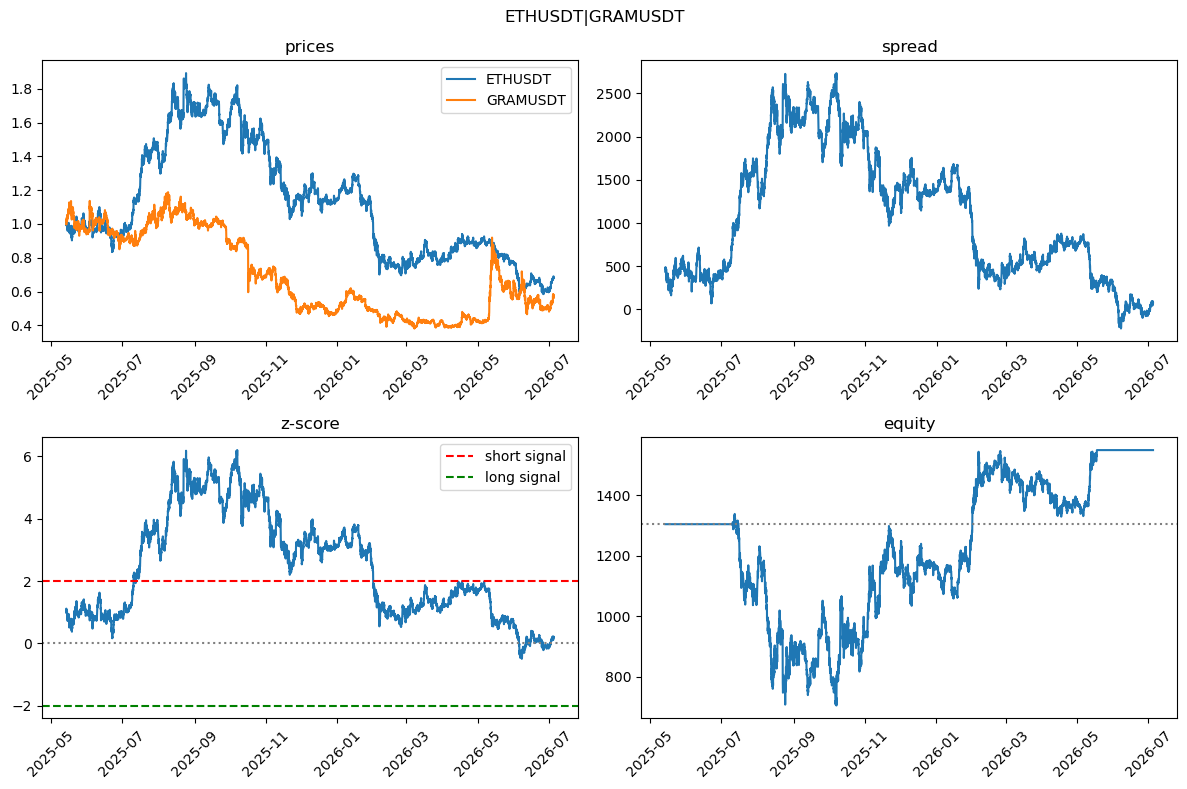

In [14]:
for ticker_a, ticker_b in zip(strong_filt['ticker_a'], strong_filt['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b, data_liquid)